In [ ]:
!pip install -q transformers

In [ ]:
from transformers import RobertaTokenizerFast, TFRobertaForSequenceClassification, pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis")
data = ["I love you", "I hate you"]
sentiment_pipeline(data)

In [ ]:
# download pre-trained emotion classification model
emotion = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

emotion(data)

In [ ]:
df = pd.read_csv('EastBlue1.csv')

In [ ]:
df.head(5)

In [ ]:
df.drop(['web-scraper-order', 'web-scraper-start-url'], axis=1, inplace=True)

In [ ]:
df.head(5)

In [ ]:
MAX_LENGTH = 512  # ขีดจำกัดของโมเดล
df['comment'] = df['comment'].apply(lambda x: x[:MAX_LENGTH] if isinstance(x, str) else "")
#ตัดข้อความให้สั้นลงก่อนประมวลผล

In [ ]:
df['comment'] = df['comment'].str.replace('\n', '').str.replace('\r', '').str.replace('', '')

In [ ]:
df['sentiment'] = df.comment.apply(lambda x: sentiment_pipeline(x)[0]['label'])

In [ ]:
df['emotion'] = df.comment.apply(lambda x: emotion(x)[0]['label'])

In [ ]:
df.head(5)

,link,link-href,comment,sentiment,emotion
0,01x01 - I'm Luffy! The Man Who Will Become the...,https://transcripts.foreverdreaming.org/viewto...,"So tough ""I'm Luffy!The man who will become th...",NEGATIVE,surprise
1,01x02 - The Great Swordsman Appears! Pirate Hu...,https://transcripts.foreverdreaming.org/viewto...,Oh!What a nice day!Keep going this way!We'll s...,POSITIVE,joy
2,01x03 - Morgan vs. Luffy! Who's This Beautiful...,https://transcripts.foreverdreaming.org/viewto...,(The following episode is based on Manga ch.5:...,NEGATIVE,surprise
3,01x06 - Desperate Situation! Beast Tamer Mohji...,https://transcripts.foreverdreaming.org/viewto...,''Yuba'' ''Erumalu'' ''Nanohana'' ''Katorea'''...,NEGATIVE,sadness
4,01x04 - Luffy's Past! Enter Red-Haired Shanks!,https://transcripts.foreverdreaming.org/viewto...,(The following episode is based on Manga ch.7:...,NEGATIVE,surprise


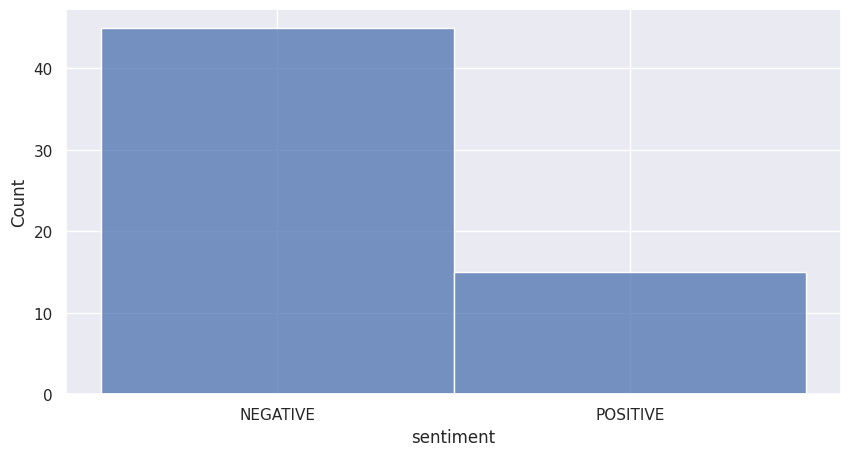

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['sentiment'])

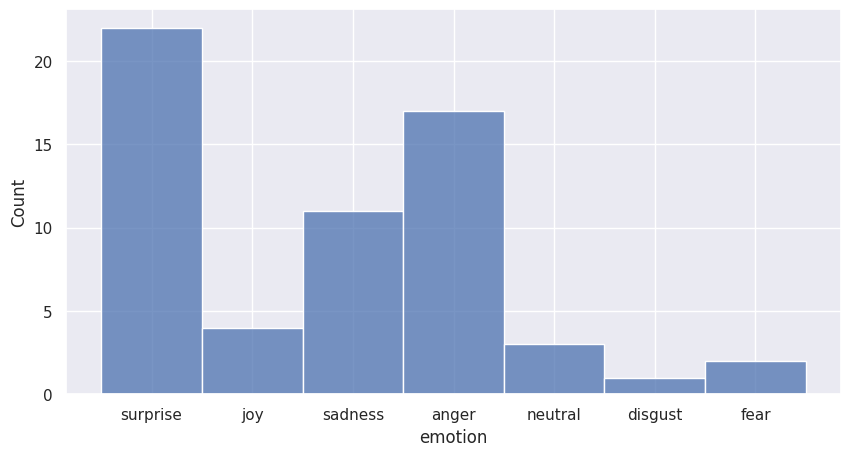

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['emotion'])

In [ ]:
df.to_csv('SoothingRelaxation-done.csv', index=False)

In [ ]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS

In [ ]:
# Wordcloud with positive
msg = df['comment'][df["sentiment"] == 'POSITIVE']
stop_words = list(STOPWORDS)
positive_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Positive Tweets - Wordcloud")
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
 # Wordcloud with negative
msg = df['comment'][df["sentiment"] == 'NEGATIVE']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
msg = df['comment']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
msg = df['comment'][df['emotion'] == 'JOY']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
